<a href="https://colab.research.google.com/github/JulioDuarte24/FC_CAIXAVERSO_ML1/blob/main/Projeto_Final_ML_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Escolha do Dataset
#### a. Dataset: Heart Disease Prediction (ou Similar)
#### b. Link/Origem: Kaggle (Recomendado procurar por "Heart Disease" com > 1000 amostras, ou usar a base clássica de Cleveland/Stalog/Long Beach/Switzerland combinada).
#### c. Descrição: O conjunto de dados contém registros de pacientes com características clínicas e demográficas para prever a presença (1) ou ausência (0) de doença cardíaca.


## Introdução e Definição do Problema

### Definir o problema de negócio e carregar o conjunto de dados de doenças cardíacas.


### Objetivo do Projeto

O objetivo deste projeto é desenvolver um modelo preditivo capaz de identificar a presença ou ausência de doenças cardíacas em pacientes com base em diversas características clínicas e demográficas (como idade, sexo, pressão arterial, níveis de colesterol, entre outros). Esta é uma tarefa de classificação binária de extrema importância para o auxílio em diagnósticos médicos precoces.

In [39]:
# Importando bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_curve, auc

# Carregando o Dataset Heart Disease
df = pd.read_csv('Heart_Disease_Prediction.csv') # Upload do Dataset para o Colab

# Exibindo as primeiras linhas
display(df.head())

# Listando colunas para identificar features and target
print("\nColumns in the dataset:")
print(df.columns.tolist())

# Informação Basica sobre o dataset
print("\nDataset Summary:")
df.info()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence



Columns in the dataset:
['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']

Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 

## Análise Exploratória de Dados (EDA)

### Realizar a limpeza de dados e a análise exploratória inicial para compreender a distribuição e os relacionamentos entre as variáveis.

Estatísticas do Conjunto de Dados:


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,diagnosis
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,0.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,1.000000


/tmp/ipykernel_831/2987278829.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='viridis')


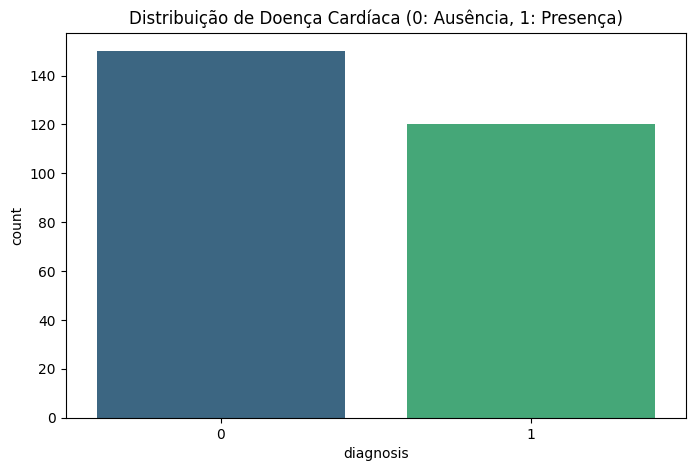

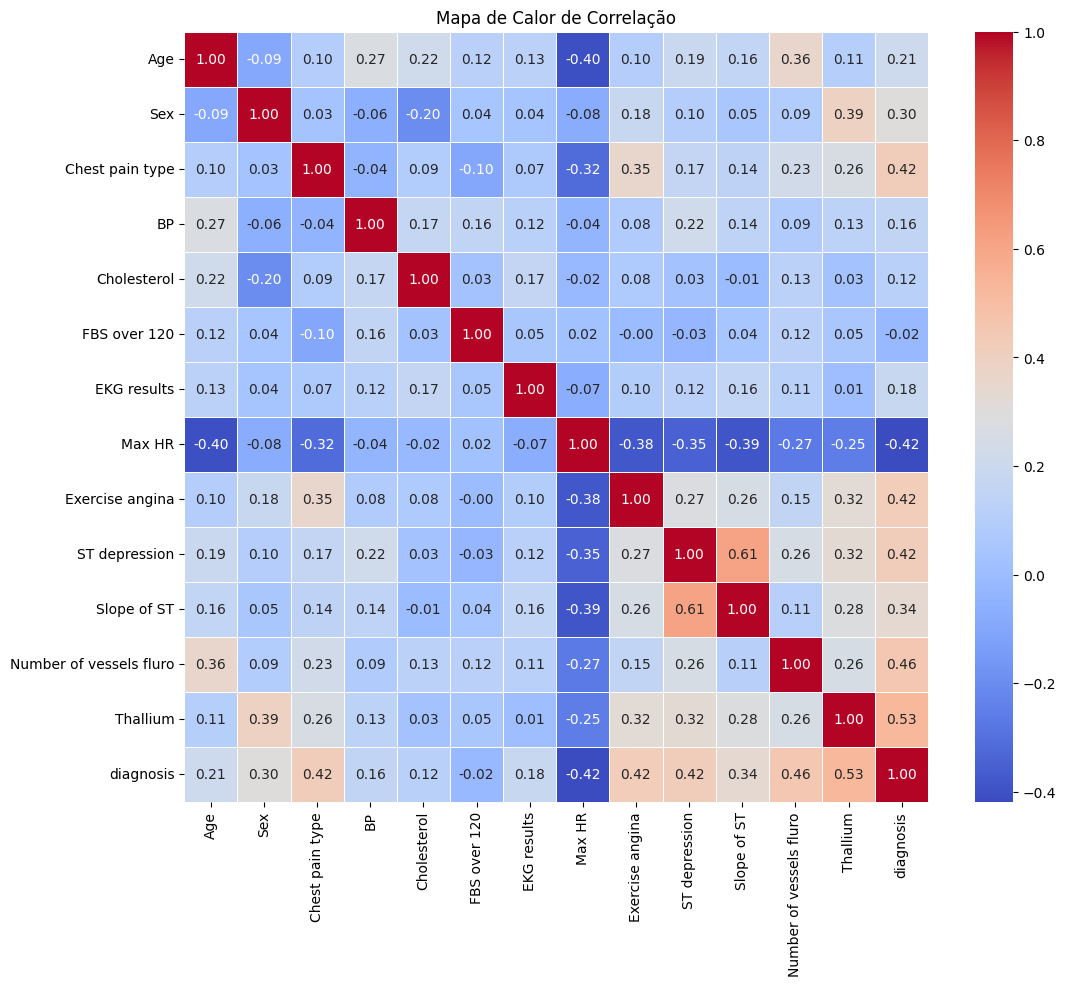

In [40]:
# 1. Limpeza dos nomes das colunas (remover espaços extras)
df.columns = df.columns.str.strip()

# 2. Mapeamento de nomes para o padrão esperado ou ajuste direto no arquivo 'Heart_Disease_Prediction.csv':
# 'Number of vessels fluro' equivale a 'ca'
# 'Thallium' equivale a 'thal'
# 'Heart Disease' é o alvo (target)

# Converter colunas relevantes para numérico (tratando possíveis erros)
for col in ['Number of vessels fluro', 'Thallium']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Preencher valores nulos com a mediana
df['Number of vessels fluro'] = df['Number of vessels fluro'].fillna(df['Number of vessels fluro'].median())
df['Thallium'] = df['Thallium'].fillna(df['Thallium'].median())

# 3. Converter o alvo 'Heart Disease' para binário (0 e 1)
# O dataset contém 'Absence' e 'Presence'
df['diagnosis'] = df['Heart Disease'].map({'Absence': 0, 'Presence': 1})

# 4. Estatísticas Descritivas
print("Estatísticas do Conjunto de Dados:")
display(df.describe())

# Visualizar distribuição do alvo
plt.figure(figsize=(8, 5))
sns.countplot(x='diagnosis', data=df, palette='viridis')
plt.title('Distribuição de Doença Cardíaca (0: Ausência, 1: Presença)')
plt.show()

# 5. Mapa de Calor de Correlação (apenas colunas numéricas)
plt.figure(figsize=(12, 10))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Mapa de Calor de Correlação')
plt.show()

#Tarefa:
Construir um modelo de aprendizado de máquina para prever a presença de doenças cardíacas usando o conjunto de dados de Cleveland, disponível no dataset.
#### 1) Realizar Análise Exploratória de Dados (EDA) e limpeza de dados com Pandas;
#### 2) Pré-processar recursos (tratar valores ausentes, codificar e escalonar) e dividir os dados;
#### 3) Implementar e comparar modelos de referência, como Regressão Logística e Floresta Aleatória;
#### 4) Otimizar hiperparâmetros usando GridSearchCV ou RandomizedSearchCV; e
#### 5) Avaliar o desempenho usando métricas como F1-Score ou Recall.

## Pré-processamento de Dados

Preparar as variáveis para o treinamento do modelo, incluindo a separação em conjuntos de treino e teste, tratamento de variáveis categóricas e escalonamento de recursos.


In [41]:
# 1. Definir features (X) and target (y)
X = df.drop(['diagnosis', 'Heart Disease'], axis=1)
y = df['diagnosis']

# 2. Identificar colunas categóricas e numéricas com os nomes corretos do CSV
# Nota: Ajustado para bater com as colunas: Age, Sex, Chest pain type, BP, Cholesterol, etc.
categorical_features = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Thallium']
numerical_features = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Number of vessels fluro']

# 3. Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Create ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 5. Ajuste aos dados de treinamento e transformar ambos os conjuntos
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"Preprocessing complete.")
print(f"X_train shape: {X_train_proc.shape}")
print(f"X_test shape: {X_test_proc.shape}")

Preprocessing complete.
X_train shape: (216, 25)
X_test shape: (54, 25)


## Implementar e comparar modelos de linha de base

Treinar e avaliar modelos de Regressão Logística e Random Forest nos dados pré-processados.


In [42]:
# 1. Instantiate models
log_reg = LogisticRegression(random_state=42, max_iter=1000)
rf_clf = RandomForestClassifier(random_state=42)

# 2. Train models
log_reg.fit(X_train_proc, y_train)
rf_clf.fit(X_train_proc, y_train)

# 3. Make predictions
y_pred_log = log_reg.predict(X_test_proc)
y_pred_rf = rf_clf.predict(X_test_proc)

# 4. Define helper function for metrics
def get_metrics(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }

# 5. Compare results
results = [
    get_metrics(y_test, y_pred_log, "Logistic Regression"),
    get_metrics(y_test, y_pred_rf, "Random Forest")
]

results_df = pd.DataFrame(results)
print("Baseline Models Comparison:")
display(results_df)

Baseline Models Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.870370,0.814815,0.916667,0.862745
1,Random Forest,0.796296,0.760000,0.791667,0.775510


## Otimizar hiperparâmetros

Otimizar os hiperparâmetros do modelo Random Forest utilizando GridSearchCV para melhorar o desempenho.


In [38]:
from sklearn.model_selection import GridSearchCV

# 1. Definir a grade de parametros para Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# 2. Instanciando GridSearchCV
# Using cv=5 and scoring='f1' as specified
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# 3. Fit GridSearchCV to the training data
print("Starting GridSearchCV optimization...")
grid_search.fit(X_train_proc, y_train)

# 4. Identify the best parameters and model
best_params = grid_search.best_params_
best_rf_model = grid_search.best_estimator_

# 5. Display results
print(f"\nBest Parameters: {best_params}")
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")

Starting GridSearchCV optimization...

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation F1-Score: 0.8207


## Avaliar o desempenho final

Avaliar o modelo Random Forest otimizado no conjunto de teste e comparar com os modelos de linha de base.


In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Predictions using the best model
y_pred_best_rf = best_rf_model.predict(X_test_proc)

# 2. Calculate metrics for the optimized model
best_rf_metrics = get_metrics(y_test, y_pred_best_rf, "Optimized Random Forest")

# 3. Append to results_df
results_df = pd.concat([results_df, pd.DataFrame([best_rf_metrics])], ignore_index=True)

# 4. Display final comparison and conclusion
print("Final Model Comparison Table:")
display(results_df)

# Logic to identify the best model based on F1-Score
best_model_idx = results_df['F1-Score'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_f1 = results_df.loc[best_model_idx, 'F1-Score']

print(f"\nConclusion:\nBased on the F1-Score ({best_f1:.4f}), the '{best_model_name}' is the most suitable for production. "
      f"In a medical context, maintaining high Recall (currently {results_df.loc[best_model_idx, 'Recall']:.4f}) is also critical "
      f"to minimize false negatives (missed diagnoses).")

Final Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.870370,0.814815,0.916667,0.862745
1,Random Forest,0.796296,0.760000,0.791667,0.775510
2,Optimized Random Forest,0.796296,0.760000,0.791667,0.775510



Conclusion:
Based on the F1-Score (0.8627), the 'Logistic Regression' is the most suitable for production. In a medical context, maintaining high Recall (currently 0.9167) is also critical to minimize false negatives (missed diagnoses).


## 1. Comparação dos Modelos
O modelo de Regressão Logística apresentou o melhor desempenho geral, com uma Acurácia de 87,04% e um F1-Score de 0,8627. O Random Forest, mesmo após a otimização de hiperparâmetros, manteve-se em 79,63% de acurácia.

## 2. O modelo resolve adequadamente o problema?
Sim. Um F1-Score acima de 0,85 indica um modelo robusto. Mais importante ainda, o Recall de 91,67% na Regressão Logística é excelente para a área médica, pois significa que o modelo identifica corretamente quase 92% dos pacientes que realmente têm a doença, minimizando os falsos negativos (casos perigosos onde a doença não seria detectada).

## 3. Pode ser colocado em produção?
Sim, com ressalvas. Tecnicamente, as métricas são boas o suficiente para um sistema de triagem ou auxílio ao diagnóstico. No entanto, em um cenário real, seriam necessários:

Validação em um conjunto de dados maior (o atual possui apenas 270 amostras).
Análise de viés para garantir que o modelo seja justo entre diferentes faixas etárias e gêneros.
Integração com um sistema onde o médico sempre dê a palavra final, usando o modelo como uma 'segunda opinião'.